In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
data = pd.read_excel('Amazon.xlsx')
data.head()

,Unnamed: 0,Velocidad Entrega,Precio,Durabilidad,Imagen Producto,Valor Educativo,Servicio Retorno,Tamano Paquete,Calidad Producto,Numero Estrellas
0,Adam,205,3,345,235,24,23,26,21,17
1,Anna,9,15,315,33,25,4,42,215,28
2,Bernard,17,26,285,3,43,27,41,26,33
3,Edward,135,5,355,295,18,23,39,195,17
4,Emilia,3,45,48,39,34,46,225,34,43


In [54]:
from sklearn.preprocessing import normalize
data_scaled = data.drop('Unnamed: 0', axis=1)
data_scaled = normalize(data_scaled)

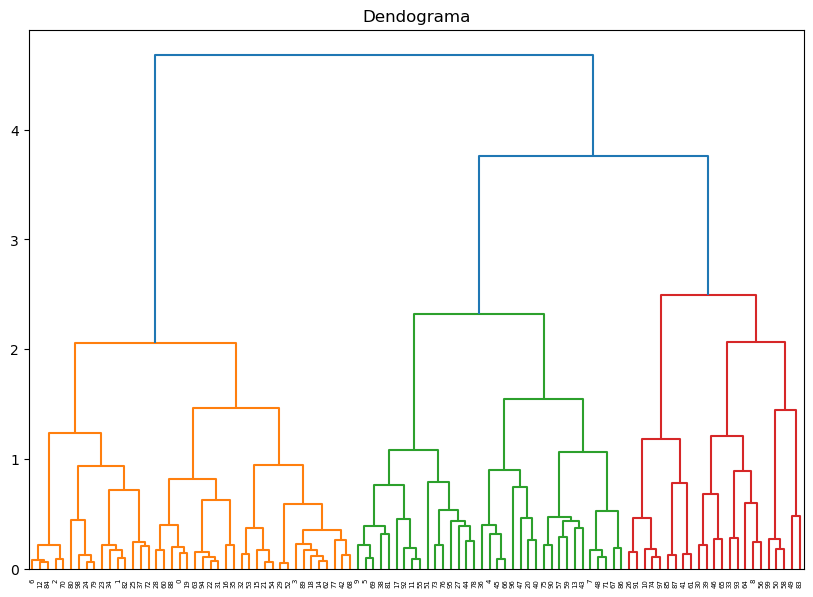

In [19]:
import scipy.cluster .hierarchy as shc
plt.figure(figsize=(10,7))
plt.title('Dendograma')
dend = shc.dendrogram(shc.linkage(data_scaled, method='ward'))

In [20]:
colores_unicos = set(dend['color_list'])
num_clusters_optimo = len(colores_unicos) - 1
num_clusters_optimo

3

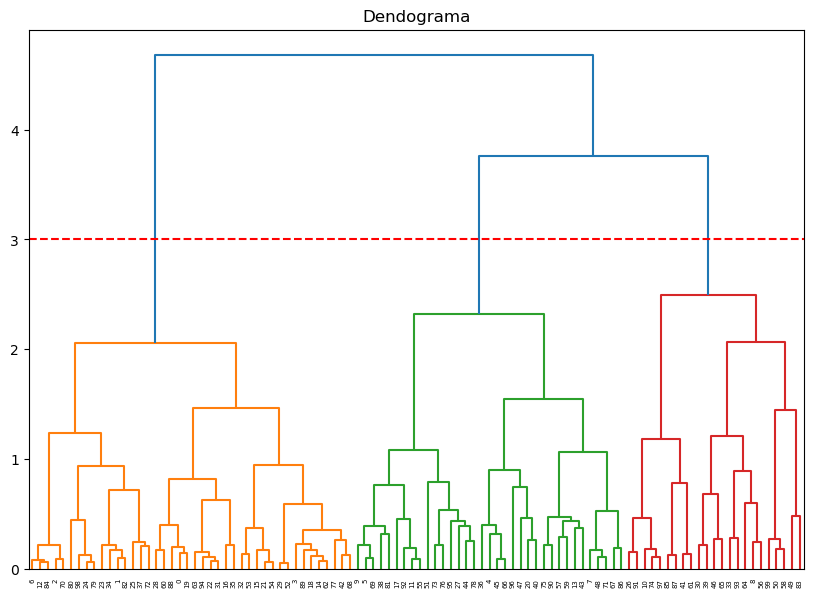

In [22]:
plt.figure(figsize=(10, 7))
plt.title('Dendograma')
dend = shc.dendrogram(shc.linkage(data_scaled, method='ward'))
plt.axhline(y=3, color='r', linestyle='--')

In [25]:
from sklearn import decomposition
campos = data_scaled
pca = decomposition.PCA(n_components=2)
pca.fit(campos)
campos = pca.transform(campos)

In [26]:
from sklearn.cluster import AgglomerativeClustering
cluster = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
grupos = cluster.fit_predict(data_scaled)
grupos

array([1, 1, 1, 1, 2, 2, 1, 2, 0, 2, 0, 2, 1, 2, 1, 1, 1, 2, 1, 1, 2, 1,
       1, 1, 1, 1, 0, 2, 1, 1, 0, 1, 1, 0, 1, 1, 2, 1, 2, 0, 2, 0, 1, 2,
       2, 2, 0, 2, 2, 0, 0, 2, 1, 1, 1, 2, 0, 2, 0, 2, 1, 0, 1, 1, 0, 0,
       2, 2, 1, 2, 1, 2, 1, 2, 0, 2, 2, 1, 2, 1, 1, 2, 1, 0, 1, 0, 2, 0,
       1, 1, 2, 0, 2, 0, 1, 2, 2, 0, 1, 0])

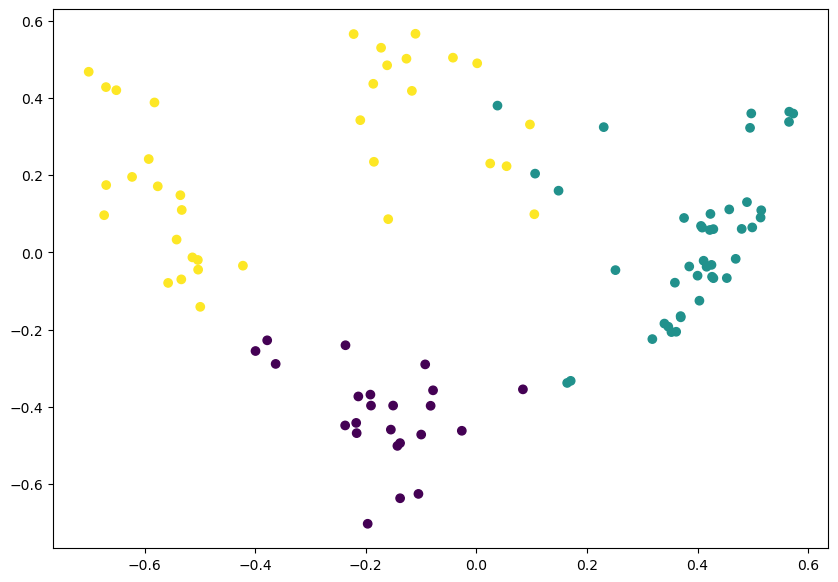

In [27]:
plt.figure(figsize=(10,7))
plt.scatter(campos[:,0], campos[:,1], c=cluster.labels_)

In [28]:
dataframe = pd.DataFrame(grupos, columns=['grupo'])
dataframe

,grupo
0,1
1,1
2,1
3,1
4,2
...,...
95,2
96,2
97,0
98,1


In [31]:
dataframe2 = pd.concat([data, dataframe], axis=1, join='inner')
dataframe2

,Unnamed: 0,Velocidad Entrega,Precio,Durabilidad,Imagen Producto,Valor Educativo,Servicio Retorno,Tamano Paquete,Calidad Producto,Numero Estrellas,grupo
0,Adam,205,3,345,235,24,23,26,21,17,1
1,Anna,9,15,315,33,25,4,42,215,28,1
2,Bernard,17,26,285,3,43,27,41,26,33,1
3,Edward,135,5,355,295,18,23,39,195,17,1
4,Emilia,3,45,48,39,34,46,225,34,43,2
...,...,...,...,...,...,...,...,...,...,...,...
95,Teofan,3,8,32,25,7,21,42,17,1,2
96,Teofil,305,25,46,24,33,28,355,26,45,2
97,Teofila,1,14,26,25,24,27,42,185,23,0
98,Teon,155,11,335,34,26,29,42,215,27,1


In [53]:
# Con base en los resultados de su análisis, ¿qué productos recomendaría a Salomé? ¿Qué productos recomendaría a Stephanía? 
# ¿Qué productos recomendaría a Lydia?
name = 'Lydia'
persona_g1 = 'Adam'
result = dataframe2.loc[dataframe2['Unnamed: 0'] == name, 'grupo'].iloc[0]

# Ya que Lydia se encuentra en el grupo 1, le recomendaría los productos que han comprado otras personas del mismo grupo
print(f'{name} se encuentra en el grupo {result}')
print(f'Recomendaría a {name} los mismos productos que compró {persona_g1}')

Lydia se encuentra en el grupo 1
Recomendaría a Lydia los mismos productos que compró Adam
